<a href="https://colab.research.google.com/github/waldeyr/workshop_cgdes/blob/main/workshop_cgdes_14_marco_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Convolutional Neural Network - CNN**, para reconhecimento de monócitos e limfócitos

---



Os leucócitos ou glóbulos brancos, que são células de defesa integrantes do sistema
imunológico.



1.   Granulócitos também chamados de polimorfonucleares, apresentam núcleo com vários lóbulos e contêm grânulos específicos no citoplasma.

*   Neutrófilos
*   Eosinófilos
*   Basófilos


2.   Agranulócitos ou mononucleares, são células que não apresentam grânulos específicos citoplasmáticos.

*   Monócitos
*   Linfócitos


Dataset: https://data.mendeley.com/datasets/snkd93bnjr/1

Trabalho do Marcos Wesley: https://github.com/Marcos314/CNN_Leukocyte_Classification









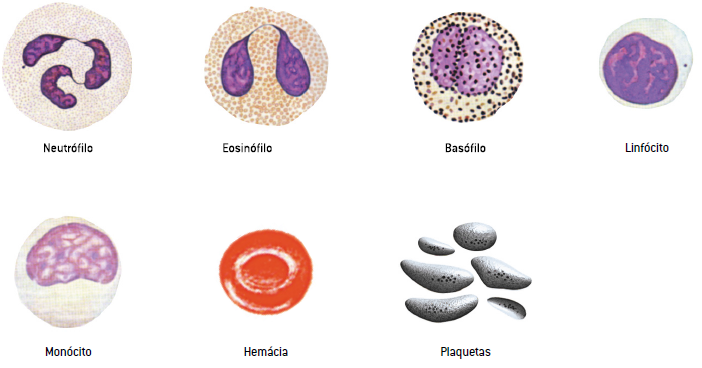

Fonte da figura: https://bityli.com/MFTqI

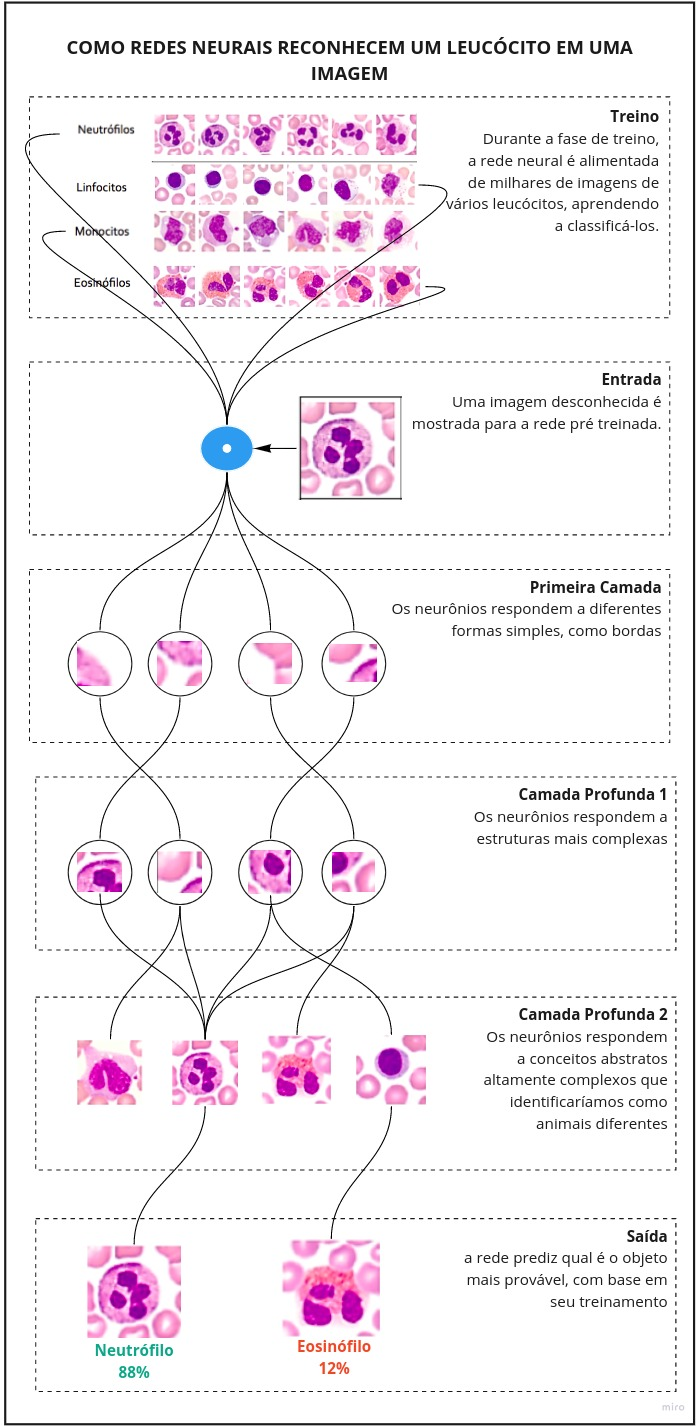

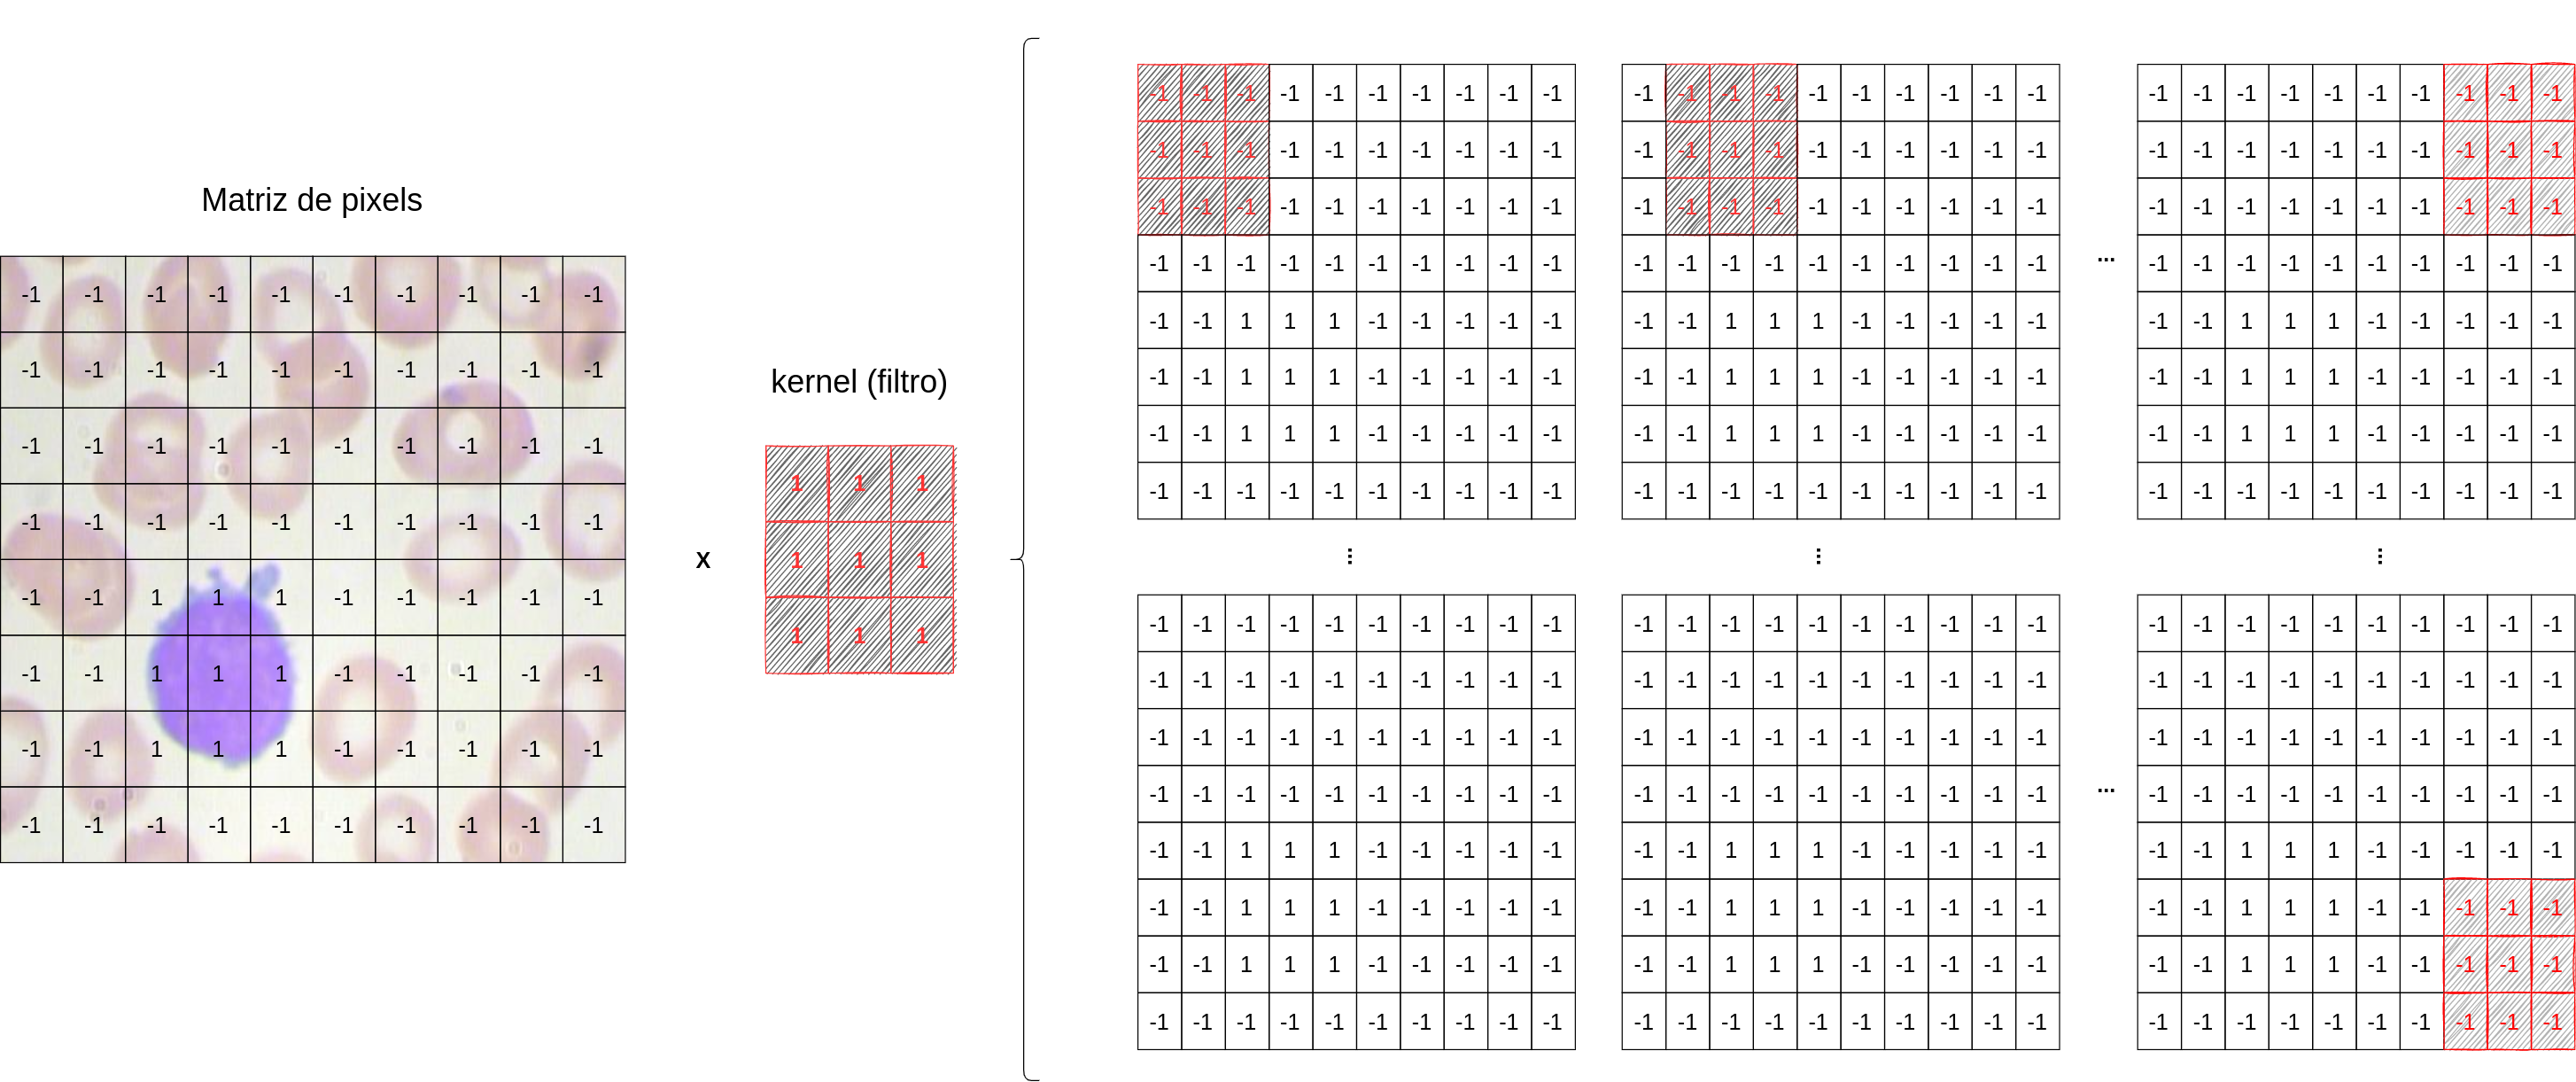

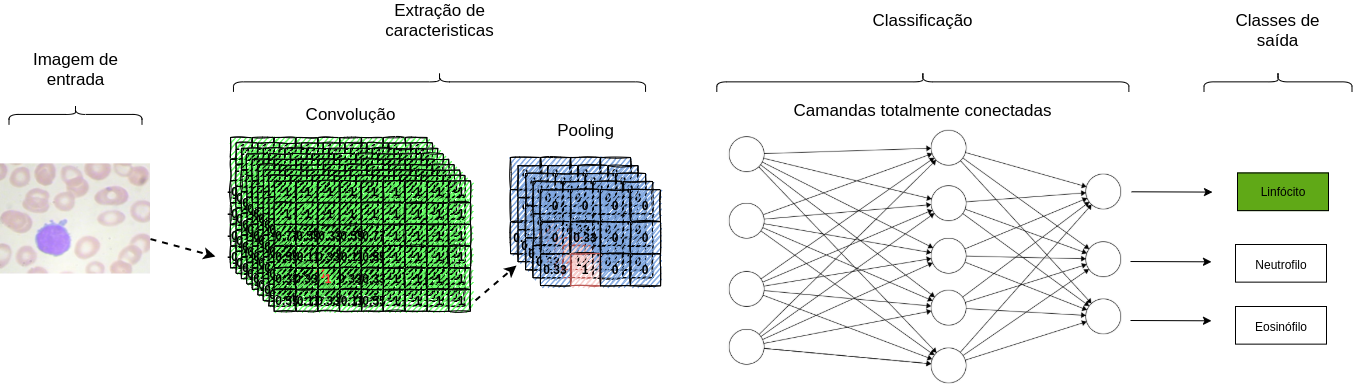

As camadas convolucionais funcionam como extratores de características (RAWAT;
WANG, 2017).

Basicamente, a imagem é organizada em uma matriz de pixels, sobre a qual incidem filtros de um determinada dimensão ou kernel com tamanho definido, geralmente 3x3 ou 5x5 (VAZ; BALAJI, 2021).

Há filtros (kernel) para cada característica encontrada numa imagem, por exemplo um ponto vermelho.

Ao percorrer a matriz, os filtros são multiplicados repetidamente em uma operação linear produzindo uma nova matriz (mapa de características) para cada filtro em cada imagem dada (VAZ; BALAJI, 2021).

Os neurônios nas camadas convolucionais são organizados em mapas de características (LECUN; BENGIO; HINTON, 2015).

Em seguida esses mapas são “empilhados” na camada chamada *Pooling* e em seguida sofre uma redução de dimensionalidade na camada de *Flattening*.

* RAWAT, W.; WANG, Z. Deep convolutional neural networks for image classification: a comprehensive review. Neural computation, [S.l.], v.29, n.9, p.2352–2449, 2017.
* VAZ, J. M.; BALAJI, S. Convolutional neural networks (CNNs): concepts and applications in pharmacogenomics. Molecular Diversity, [S.l.], p.1–16, 2021.
* LECUN, Y.; BENGIO, Y.; HINTON, G. Deep learning. Nature, [S.l.], v.521, n.7553, p.436–444, 2015.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

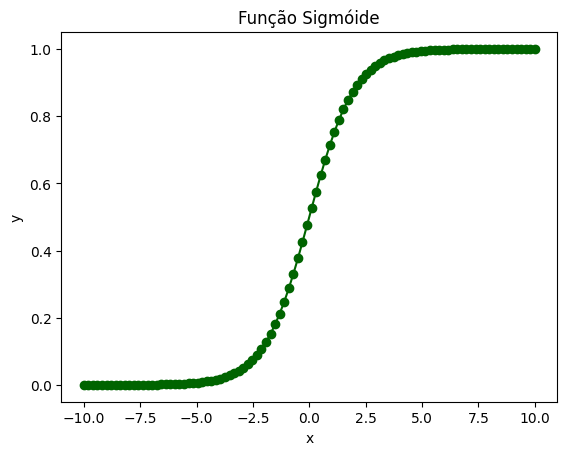

In [2]:
x = np.linspace(-10, 10, 100)
z = 1/(1 + np.exp(-x))

plt.plot(x, z, color = 'darkgreen', marker = "o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Função Sigmóide")
plt.show()

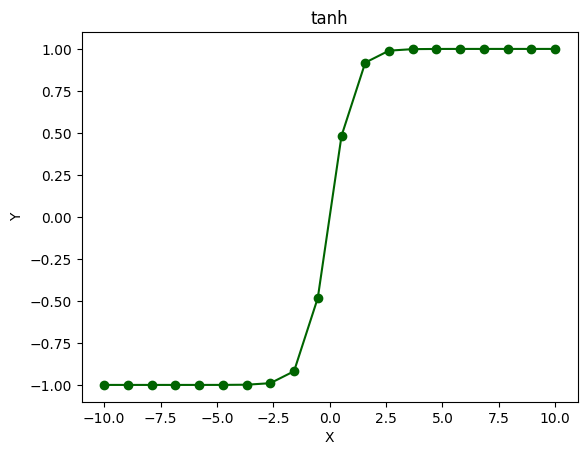

In [3]:
x = np.linspace(-10, 10, 20)
y = np.tanh(x)

# red for numpy.tanh()
plt.plot(x, y, color = 'darkgreen', marker = "o")
plt.title("tanh")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

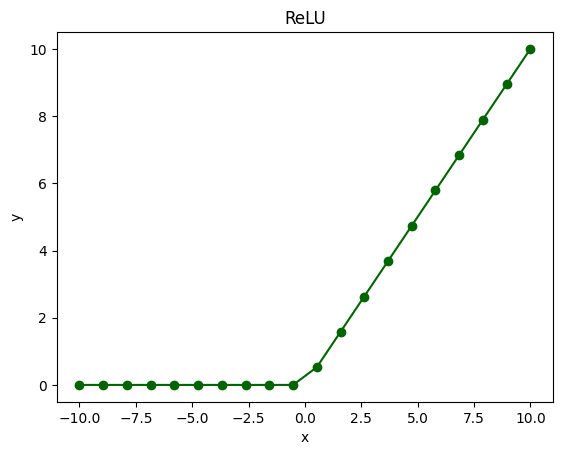

In [4]:
def ReLU(x):
    x1=[]
    for i in x:
        if i<0:
            x1.append(0)
        else:
            x1.append(i)

    return x1

x = np.linspace(-10, 10, 20)
y = ReLU(x)
plt.plot(x, y, color = 'darkgreen', marker = "o")
plt.xlabel("x")
plt.ylabel("y")
plt.title('ReLU')
plt.show()

## Construindo uma rede neural convolucional para identificar

### Dataset

In [5]:
import os
import zipfile

# Define the path to the zip file and the destination folder
zip_file_path = "/content/monocytes_and_lymphocytes.zip"
destination_folder = "/content/images"

# Create the destination folder if it doesn't exist
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# Extract the zip file to the destination folder
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(destination_folder)
    print(f"Successfully unzipped '{zip_file_path}' to '{destination_folder}'")
except FileNotFoundError:
    print(f"Error: File '{zip_file_path}' not found.")
except zipfile.BadZipFile:
    print(f"Error: Invalid zip file '{zip_file_path}'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully unzipped '/content/monocytes_and_lymphocytes.zip' to '/content/images'


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os

**Passo 2: Configurar o Diretório das Imagens**

In [7]:
train_dir = '/content/images'

In [8]:
print(os.listdir(train_dir))

['monocyte', 'lymphocyte', '__MACOSX']


**Passo 3: Pré-processamento e Aumento de Dados**

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',  # Detecta automaticamente as classes lymphocyte e monocyte
    subset='training',
    classes=['lymphocyte', 'monocyte']  # Especifica as subpastas a serem usadas
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    classes=['lymphocyte', 'monocyte']  # Especifica as subpastas a serem usadas
)

Found 2108 images belonging to 2 classes.
Found 526 images belonging to 2 classes.


O conjunto de dados não é muito grande, então podemos aplicar augmentation para expandi-lo

In [10]:
from PIL import Image
import os

image_dir = '/content/images/monocyte'

for filename in os.listdir(image_dir):
    if filename.endswith(('.jpg', '.jpeg', '.png')):  # Add other image extensions if needed
        filepath = os.path.join(image_dir, filename)
        try:
            img = Image.open(filepath)
            rotated_img = img.rotate(90)
            rotated_filename = os.path.splitext(filename)[0] + '_rotated.jpg'  # Or other suitable extension
            rotated_filepath = os.path.join(image_dir, rotated_filename)
            rotated_img.save(rotated_filepath)
        except IOError:
            print(f"Cannot rotate image: {filename}")

image_dir = '/content/images/lymphocyte'

for filename in os.listdir(image_dir):
    if filename.endswith(('.jpg', '.jpeg', '.png')):  # Add other image extensions if needed
        filepath = os.path.join(image_dir, filename)
        try:
            img = Image.open(filepath)
            rotated_img = img.rotate(90)
            rotated_filename = os.path.splitext(filename)[0] + '_rotated.jpg'  # Or other suitable extension
            rotated_filepath = os.path.join(image_dir, rotated_filename)
            rotated_img.save(rotated_filepath)
        except IOError:
            print(f"Cannot rotate image: {filename}")


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.1,   # Increased augmentation: width shift
    height_shift_range=0.1,  # Increased augmentation: height shift
    brightness_range=[0.5, 1.5], # Increased augmentation: brightness
    fill_mode='nearest',     # Strategy for filling newly created pixels
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',  # Detecta automaticamente as classes lymphocyte e monocyte
    subset='training',
    classes=['lymphocyte', 'monocyte']  # Especifica as subpastas a serem usadas
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    classes=['lymphocyte', 'monocyte']  # Especifica as subpastas a serem usadas
)

Found 4380 images belonging to 2 classes.
Found 1094 images belonging to 2 classes.


**Passo 4: Construir o Modelo da CNN**

In [12]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Passo 5: Treinar o Modelo**

In [13]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 282ms/step - accuracy: 0.8080 - loss: 0.4241 - val_accuracy: 0.9513 - val_loss: 0.1375
Epoch 2/20
  1/136 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9375 - loss: 0.1556

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9375 - loss: 0.1556 - val_accuracy: 0.9458 - val_loss: 0.1447
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 35s 256ms/step - accuracy: 0.9311 - loss: 0.1858 - val_accuracy: 0.9522 - val_loss: 0.1291
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9375 - loss: 0.0749 - val_accuracy: 0.9439 - val_loss: 0.1708
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 254ms/step - accuracy: 0.9451 - loss: 0.1351 - val_accuracy: 0.9660 - val_loss: 0.0897
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9688 - loss: 0.0727 - val_accuracy: 0.9623 - val_loss: 0.0967
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 253ms/step - accuracy: 0.9558 - loss: 0.1133 - val_accuracy: 0.9421 - val_loss: 0.1477
Epoch 8/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 1.0000 - loss: 0.1022 - val_accuracy: 0.9384 - val_loss: 0.1478
Epoch 9/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 34s 254ms/step - accuracy: 0.9608 - loss: 0.1056 - val_accurac

**Passo 6: Avaliar o Modelo**

In [14]:
loss, accuracy = model.evaluate(validation_generator)
print(f'Loss: {loss}, Accuracy: {accuracy}')

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.9808 - loss: 0.0547
Loss: 0.0572052001953125, Accuracy: 0.9798902869224548


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step


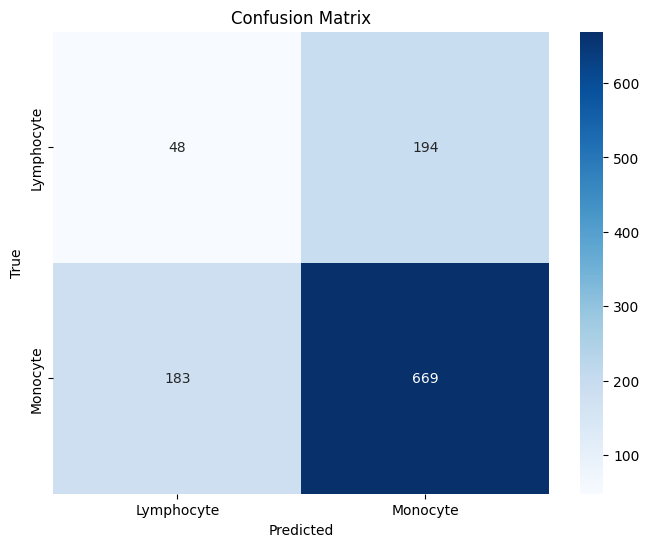

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Assuming you have 'validation_generator' and 'model' defined
# Predict probabilities for the validation set
y_pred_prob = model.predict(validation_generator)

# Get predicted classes for the validation set using a threshold of 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Get true labels from the validation generator
y_true = validation_generator.classes

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lymphocyte', 'Monocyte'],
            yticklabels=['Lymphocyte', 'Monocyte'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted classes for the validation set
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate precision, recall, and F1-score
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


Precision: 0.7752027809965237
Recall: 0.7852112676056338
F1-score: 0.7801749271137026


**Passo 7: Visualizar os Resultados do Treinamento**

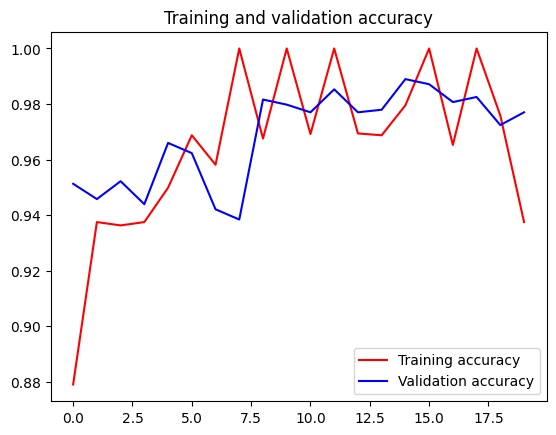

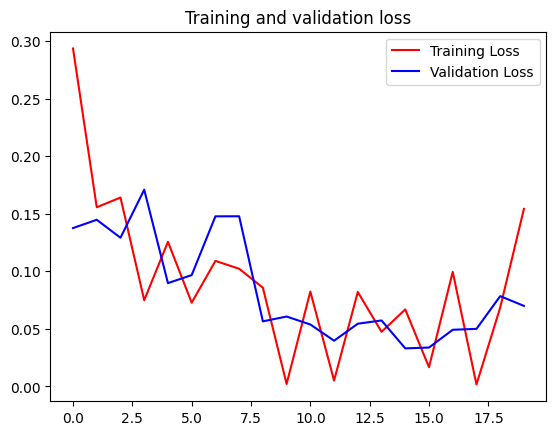

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step


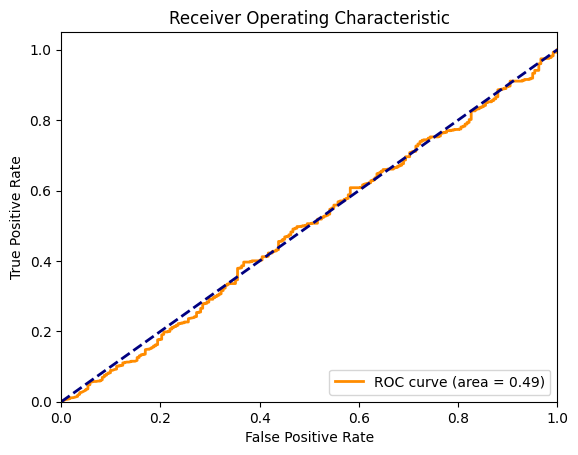

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the validation set
y_pred_prob = model.predict(validation_generator)

# Get true labels for the validation set
y_true = validation_generator.classes

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
